In [1]:
import pandas as pd
import numpy as np
import hdbscan
df = pd.read_csv("karnataka_crime_hotspots.csv")

In [2]:
print(df.shape)

(14525, 5)


In [3]:
print(df.head())

    latitude  longitude  crime_count            city         district
0  12.949244  77.611599          629  Bengaluru City  Bangalore Urban
1  12.955459  77.618642          512  Bengaluru City  Bangalore Urban
2  12.969157  77.616618          804  Bengaluru City  Bangalore Urban
3  12.964903  77.613317          964  Bengaluru City  Bangalore Urban
4  12.967772  77.615125          846  Bengaluru City  Bangalore Urban


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   latitude     14525 non-null  float64
 1   longitude    14525 non-null  float64
 2   crime_count  14525 non-null  int64  
 3   city         14525 non-null  str    
 4   district     14525 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 567.5 KB
None


In [5]:
print(df.describe())

           latitude     longitude   crime_count
count  14525.000000  14525.000000  14525.000000
mean      14.235857     76.457186    437.842134
std        1.616219      1.059930    222.711533
min       11.641178     74.075790      1.000000
25%       12.958758     75.662529    304.000000
50%       13.375725     76.624851    439.000000
75%       15.463672     77.557864    592.000000
max       18.368041     78.436752   1000.000000


In [6]:
print(df.isnull().sum())

latitude       0
longitude      0
crime_count    0
city           0
district       0
dtype: int64


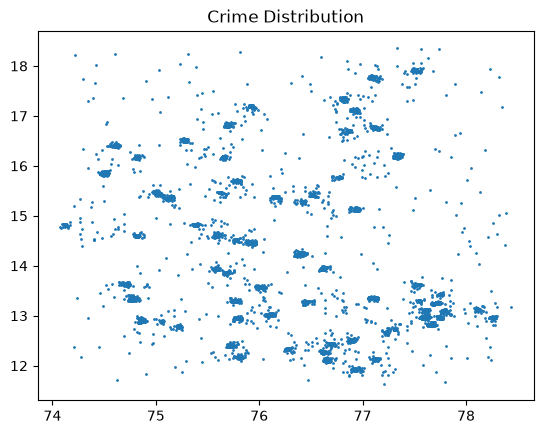

In [8]:
import matplotlib.pyplot as plt
plt.scatter(df['longitude'], df['latitude'], s=1)
plt.title("Crime Distribution")
plt.show()

In [11]:
df = df.groupby('district').apply(lambda x: x.sample(min(len(x), 800)))

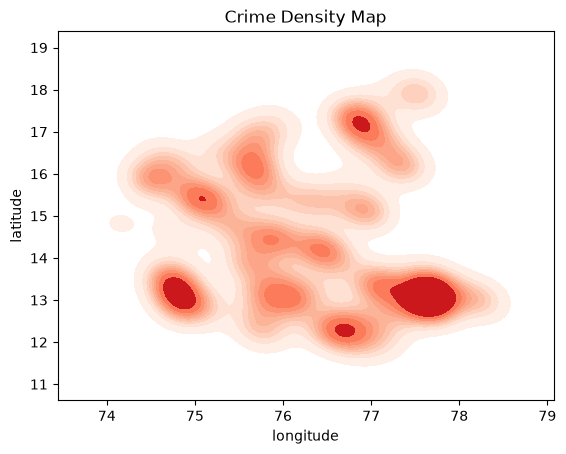

In [12]:
import seaborn as sns

sns.kdeplot(
    x=df['longitude'],
    y=df['latitude'],
    fill=True,
    cmap="Reds"
)
plt.title("Crime Density Map")
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

coords_scaled = StandardScaler().fit_transform(df[['latitude','longitude']])

In [14]:
# Remove duplicates
df = df.drop_duplicates(subset=['latitude','longitude'])

# Convert to radians (for geo data)
coords = np.radians(df[['latitude', 'longitude']])

# Apply HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,     # similar to min_samples in DBSCAN
    min_samples=5,           # controls noise sensitivity
    metric='haversine'       # same as your DBSCAN
)

labels = clusterer.fit_predict(coords)

# Results
df['cluster'] = labels

print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise:", list(labels).count(-1))

Clusters: 82
Noise: 756


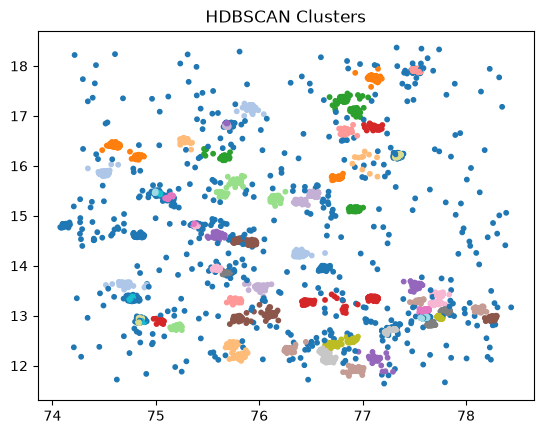

In [15]:
import matplotlib.pyplot as plt

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['cluster'],
    cmap='tab20',
    s=10
)
plt.title("HDBSCAN Clusters")
plt.show()

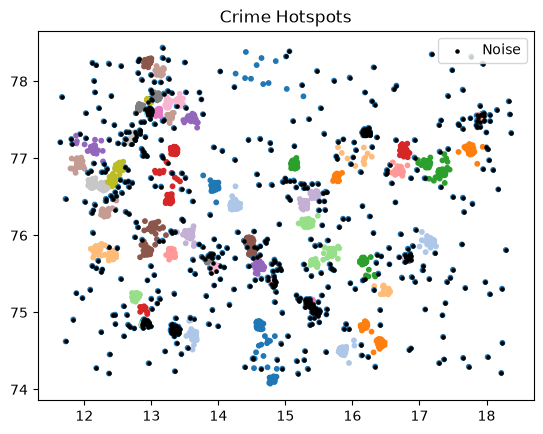

In [18]:
plt.scatter(
    df['latitude'],
    df['longitude'],
    c=df['cluster'],
    cmap='tab20',
    s=10
)

# Highlight noise separately
noise = df['cluster'] == -1
plt.scatter(
    df[noise]['latitude'],
    df[noise]['longitude'],
    c='black',
    s=5,
    label='Noise'
)

plt.legend()
plt.title("Crime Hotspots")
plt.show()

In [19]:
# Remove noise
clusters_df = df[df['cluster'] != -1]

# Group hotspots
hotspots = clusters_df.groupby('cluster').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'cluster': 'count'
}).rename(columns={'cluster': 'crime_count'}).reset_index()

print(hotspots)

    cluster   latitude  longitude  crime_count
0         0  14.666257  78.088039           11
1         1  14.601727  74.793310          117
2         2  14.815311  74.127655           74
3         3  13.950619  76.623295          184
4         4  14.240577  76.404101          397
..      ...        ...        ...          ...
77       77  12.970118  77.616208          114
78       78  15.475931  75.002632           56
79       79  15.457731  74.994584           22
80       80  12.964014  77.570191          108
81       81  12.943492  77.584930           54

[82 rows x 4 columns]


In [20]:
hotspots.to_csv("clean_hotspots.csv", index=False)

In [21]:
from sklearn.metrics.pairwise import haversine_distances

# Function to assign new point
def predict_hotspot(lat, lon, hotspots):
    point = np.radians([[lat, lon]])
    centers = np.radians(hotspots[['latitude', 'longitude']])
    
    distances = haversine_distances(point, centers)
    closest = np.argmin(distances)
    
    return hotspots.iloc[closest]

# Example test
test_lat = 12.98
test_lon = 77.66

result = predict_hotspot(test_lat, test_lon, hotspots)
print(result)

cluster         77.000000
latitude        12.970118
longitude       77.616208
crime_count    114.000000
Name: 77, dtype: float64


In [22]:
hotspots = pd.read_csv("clean_hotspots.csv")

In [23]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

def predict_hotspot(lat, lon):
    user = np.radians([[lat, lon]])
    centers = np.radians(hotspots[['latitude','longitude']])

    distances = haversine_distances(user, centers) * 6371  # km

    idx = np.argmin(distances)
    min_dist = distances[0][idx]

    cluster_id = hotspots.iloc[idx]['cluster']
    crime_count = hotspots.iloc[idx]['crime_count']

    # Simple risk logic
    if crime_count > 700:
        risk = "HIGH"
    elif crime_count > 300:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return {
        "cluster_id": int(cluster_id),
        "distance_km": float(min_dist),
        "risk": risk
    }